IMPORTING THE LIBRARIES

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

IMPORTING THE DATSET

In [2]:
data = load_diabetes()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

In [3]:
print(df.head())
print(df.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-0

FEATURE SELECTION

In [5]:
correlations = df.corr()['target'].sort_values(ascending = False)
print(correlations)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


CLEANING THE DATA

In [6]:
from sklearn.model_selection import train_test_split
X = df[['bmi', 's5', 'bp']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

BUILDING AND TRAINING THE MODEL

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

EVALUATING THE MODEL PERFORMANCE

In [10]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"mean squared error :{mse:.2f}")
print(f"R - squared error :{r2:.2f}")

mean squared error :2891.04
R - squared error :0.45


In [12]:
print("Coefficients :")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"Intercept : {model.intercept_:.2f}")

Coefficients :
bmi: 650.63
s5: 491.98
bp: 283.90
Intercept : 151.67


VISUALISING THE DATA

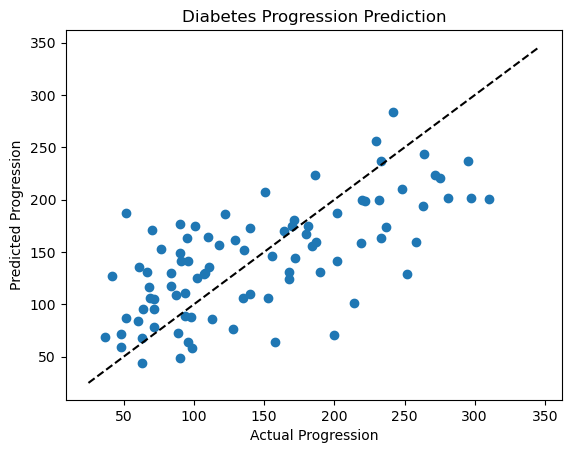

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')
plt.title('Diabetes Progression Prediction')
plt.show()

In [14]:
import joblib
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']